In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

<h1 style="text-align: center; font-weight: bold;">
بِسْمِ ٱللَّٰهِ ٱلرَّحْمَٰنِ ٱلرَّحِيمِ
</h1>

Full Name: Mohammadmahdi Bababeyk

Student ID: 4041419005

برای مدل \( f(x, \alpha) = \text{sign}(x + \alpha) \) که یک تابع تصمیم‌گیری ساده بر اساس علامت \( x + \alpha \) است، VC Dimension (بعد وی سی) برابر با *۱* خواهد بود.

*توضیح:*
- این مدل یک مرز تصمیم‌گیری خطی ساده در یک بعد دارد: یعنی بر اساس اینکه \( x \) بزرگتر یا کوچکتر از \( -\alpha \) باشد، خروجی +۱ یا -۱ تولید می‌شود.
- این مدل می‌تواند یک نقطه را به هر دو طرف (به صورت +۱ یا -۱) برچسب‌گذاری کند — یعنی یک نقطه را می‌تواند شکسته کند.
- اما برای دو نقطه، مثلاً \( x_1 < x_2 \)، اگر بخواهیم برچسب‌های \( (+1, -1) \) را برای آنها تولید کنیم، این ممکن نیست — چون مدل فقط یک مرز خطی دارد و نمی‌تواند یک نقطه را +۱ و نقطه دیگر را -۱ کند اگر نقطه +۱ در سمت راست نقطه -۱ باشد (چون مرز \( -\alpha \) نمی‌تواند بین آنها قرار گیرد و همزمان این دو برچسب را تولید کند).
- بنابراین، حداکثر تعداد نقاطی که می‌تواند به هر نحوی برچسب‌گذاری کند (یعنی شکسته کند) *۱* است.

*نتیجه:*
*VC Dimension = 1*

این یک مثال کلاسیک در یادگیری ماشین است و نشان‌دهنده محدودیت مدل‌های ساده در توانایی شکستن (shattering) مجموعه‌های بزرگ‌تر از داده‌هاست.

# Deep Reinforcement Learning and the DQN Breakthrough

Reinforcement Learning (RL) is the science of learning from interaction: an *agent* takes actions in an *environment* to maximize cumulative reward. While tabular RL methods (e.g., Q-learning) work well in small, discrete state spaces, they fail catastrophically in real-world settings—where states are high-dimensional (e.g., images), continuous, and astronomically large.

Enter **Deep Reinforcement Learning (Deep RL)**: the fusion of RL with deep neural networks. By using function approximators—especially deep neural nets—we can generalize across states, enabling agents to learn policies in complex environments like video games, robotics, and autonomous systems.

However, naively combining Q-learning with neural networks is notoriously unstable. Three core challenges arise:

1. **Non-stationary targets**: The Q-learning target $ r + \gamma \max_{a'} Q(s', a') $ changes as the network updates—creating a “moving target” problem.
2. **Correlated data**: Sequential observations are highly correlated, violating i.i.d. assumptions of stochastic gradient descent.
3. **Catastrophic forgetting & divergence**: The agent may overfit to recent experiences or diverge entirely due to feedback loops.

The 2015 **Deep Q-Network (DQN)** paper by Mnih et al. ([*Human-level control through deep reinforcement learning*](https://www.nature.com/articles/nature14236)) addressed these issues with two elegant innovations:
- **Experience Replay**: Store transitions in a buffer and sample mini-batches randomly to break temporal correlations.
- **Target Network**: Maintain a separate, slowly-updated network to generate stable bootstrap targets.

Together, these ideas enabled the first deep RL agent to achieve human-level performance on multiple Atari games—launching the modern era of deep RL.

**What You’ll Do in This Assignment**

In this hands-on assignment, you will **implement DQN from scratch** and apply it to the classic control task **`CartPole-v1`**.

Though seemingly simple, `CartPole` encapsulates the core dynamics of RL: balancing exploration vs. exploitation, managing delayed rewards, and learning from sparse feedback. Success requires careful implementation of:
- A neural Q-function approximator  
- ε-greedy action selection with decay  
- Experience replay and mini-batch training  
- Target network updates (via soft Polyak averaging)

Your goal is to train an agent that **solves** the environment — defined as achieving an **average reward ≥ 475 over 100 consecutive episodes** (the standard Gymnasium benchmark).

By completing this assignment, you will not only demystify one of deep RL’s foundational algorithms but also build intuition for the practical engineering choices that separate *theory* from *working code*.


## **0. Setup & Dependencies**

First, install required packages

In [2]:
!pip install -qq torch gymnasium matplotlib numpy

Now import libraries:

In [3]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
from collections import deque
import matplotlib.pyplot as plt

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=

## **1. Understand the Environment**

`CartPole-v1`:

- State (observation): 4D vector: `[cart position, cart velocity, pole angle, pole angular velocity]`
- Action space: discrete, 2 actions — `0 = push left`, `1 = push right`
- Reward: +1 for every timestep the pole stays upright (max 500 steps/episode in v1)
- Done: when pole angle > 12° or cart position > 2.4 units (or episode hits 500 steps)

In [4]:
env = gym.make("CartPole-v1")
obs, info = env.reset()
print("Observation shape:", obs.shape)  # (4,)
print("Action space:", env.action_space)  # Discrete(2)
env.close()

Observation shape: (4,)
Action space: Discrete(2)


## **2. Design the Q-Network (Function Approximator)**

We'll use a simple fully connected neural network to approximate the Q-function:
Q(s, a; θ) ≈ expected return starting from s, taking action a, then following policy

Why a neural net? Because state space is continuous — we can’t store a table.
Architecture:

- Input: 4 (state dimension)
- Hidden layers: 2 layers, e.g., 128 → 128 units, ReLU activation
- Output: 2 (Q-values for each action)

### Practice 1: Complete the neural network that approximates Q(s, a).

In [5]:
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super(QNetwork, self).__init__()
        # Define 3 linear layers:
        # fc1: state_dim → hidden_dim
        # fc2: hidden_dim → hidden_dim
        # fc3: hidden_dim → action_dim
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, action_dim)
    
    def forward(self, x):
        # Forward pass:
        # - Apply ReLU after fc1 and fc2
        # - Return raw logits from fc3 (no softmax!)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

Test it:

In [6]:
q_net = QNetwork(state_dim=4, action_dim=2)
dummy_input = torch.randn(1, 4)
print("Output Q-values:", q_net(dummy_input))  # shape: [1, 2]

Output Q-values: tensor([[0.1541, 0.1096]], grad_fn=<AddmmBackward0>)


## **3. Implement Experience Replay Buffer**

Why?  

- Breaks correlation between consecutive samples (i.i.d. assumption for SGD).
- Reuses data → improves sample efficiency.
- Stabilizes training.

We’ll store transitions (s, a, r, s', done) in a deque (FIFO buffer).

### Practice 2: Fill in the sample method to return a batch of transitions.

In [7]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        """
        Randomly sample a batch of transitions.
        
        Returns:
            states:      np.array (batch_size, state_dim)      e.g. (batch_size, 4)
            actions:     np.array (batch_size,)
            rewards:     np.array (batch_size,)     float32
            next_states: np.array (batch_size, state_dim)      e.g. (batch_size, 4)
            dones:       np.array (batch_size,)     bool
        """
        # Randomly sample batch_size transitions from the buffer
        batch = random.sample(self.buffer, batch_size)
        
        # Unzip the batch into separate sequences
        states, actions, rewards, next_states, dones = zip(*batch)
        
        # Convert to NumPy arrays with appropriate dtypes
        return (
            np.array(states, dtype=np.float32),           # shape: (batch_size, 4)
            np.array(actions, dtype=np.int64),            # shape: (batch_size,)
            np.array(rewards, dtype=np.float32),          # shape: (batch_size,)
            np.array(next_states, dtype=np.float32),      # shape: (batch_size, 4)
            np.array(dones, dtype=np.bool_)               # shape: (batch_size,)
        )

    def __len__(self):
        return len(self.buffer)

Buffer usage:

In [8]:
buffer = ReplayBuffer(10000)
obs, _ = env.reset()
next_obs, reward, terminated, truncated, _ = env.step(env.action_space.sample())
buffer.push(obs, 1, reward, next_obs, terminated or truncated)
print("Buffer size:", len(buffer))

Buffer size: 1


## **4. Target Network (for Stable Learning)**

Problem: In naive Q-learning, the target `r + γ·maxₐ’ Q(s’, a’)` changes every time Q updates → moving target → instability.

Solution (Mnih et al., 2015): Use a target network `Q_target` with frozen weights, updated slowly (either periodically or via Polyak averaging).

We’ll use soft update:
`θ_target ← τ·θ_policy + (1−τ)·θ_target`, where τ ≈ 0.005.

In [9]:
def soft_update(target_net, policy_net, tau=0.005):
    for target_param, policy_param in zip(target_net.parameters(), policy_net.parameters()):
        target_param.data.copy_(tau * policy_param.data + (1 - tau) * target_param.data)

Initialize both networks:

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

policy_net = QNetwork(state_dim, action_dim).to(device)
target_net = QNetwork(state_dim, action_dim).to(device)
target_net.load_state_dict(policy_net.state_dict())  # copy weights
target_net.eval()  # no gradient updates for target

QNetwork(
  (fc1): Linear(in_features=4, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=2, bias=True)
)

## **5. Action Selection — ε-Greedy Exploration**

Balance exploration (try new actions) vs exploitation (use learned Q-values).

- With probability `ε`: choose random action
- With probability `1−ε`: choose `argmax_a Q(s, a)`

Decay ε over time (e.g., from 1.0 → 0.01).

### Practice 3: Implement the exploration-exploitation trade-off.

In [11]:
def select_action(state, policy_net, epsilon, action_space, device):
    """
    Select an action using ε-greedy policy.
    
    Args:
        state:          np.array of shape (4,)
        policy_net:     QNetwork instance
        epsilon:        float ∈ [0,1] — exploration probability
        action_space:   gym.spaces.Discrete (for n_actions)
        device:         torch.device ("cuda" or "cpu")

    Returns:
        action: int (0 or 1 for CartPole)
    """
    if random.random() < epsilon:
        # Exploration: choose random action
        return action_space.sample()
    
    else:
        # Exploitation: choose best action according to current policy
        with torch.no_grad():
            # Convert numpy array → torch tensor, add batch dimension
            state_tensor = torch.from_numpy(state).float().unsqueeze(0).to(device)
            
            # Forward pass through policy network → get Q-values for all actions
            q_values = policy_net(state_tensor)  # shape: [1, action_dim]
            
            # Get the action with the highest Q-value
            action = q_values.argmax(dim=1).item()  # .item() → python int
            
            return action

## **6: Training Loop — DQN Update**

For each sampled batch:

- Compute current Q-values: Q(s, a)
- Compute target Q-values:
    `y = r + γ·maxₐ’ Q_target(s’, a’)·(1 − done)`
- Loss: MSE between Q(s,a) and y
- Backprop + optimize

** Hyperparameters (tunable!)**

In [12]:
# Hyperparameters
BATCH_SIZE = 64
GAMMA = 0.99
EPS_START = 1.0
EPS_END = 0.01
EPS_DECAY = 0.995  # per episode
LR = 1e-3
BUFFER_CAPACITY = 10000
TARGET_UPDATE_FREQ = 10  # episodes (or use soft update every step)
MIN_REPLAY_SIZE = 1000  # wait before training
NUM_EPISODES = 500

**Optimizer**

In [13]:
optimizer = optim.Adam(policy_net.parameters(), lr=LR)
loss_fn = nn.MSELoss()
replay_buffer = ReplayBuffer(BUFFER_CAPACITY)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## **7. Full Training Loop**

Let’s put it all together!

In [20]:
def train_dqn():
    env = gym.make("CartPole-v1")
    episode_rewards = []
    epsilon = EPS_START

    target_net.load_state_dict(policy_net.state_dict())

    for episode in range(NUM_EPISODES):
        state, _ = env.reset()
        total_reward = 0

        while True:
            action = select_action(state, policy_net, epsilon, env.action_space, device)

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            replay_buffer.push(state, action, reward, next_state, done)
            total_reward += reward
            state = next_state

            if len(replay_buffer) > MIN_REPLAY_SIZE:
                states, actions, rewards, next_states, dones = replay_buffer.sample(BATCH_SIZE)

                states = torch.tensor(states, dtype=torch.float32, device=device)
                actions = torch.tensor(actions, dtype=torch.long, device=device)
                rewards = torch.tensor(rewards, dtype=torch.float32, device=device)
                next_states = torch.tensor(next_states, dtype=torch.float32, device=device)
                dones = torch.tensor(dones, dtype=torch.bool, device=device)

                current_q_values = policy_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)

                with torch.no_grad():
                    next_q_values = target_net(next_states).max(1)[0]
                    target_q_values = rewards + (GAMMA * next_q_values * (~dones).float())

                loss = loss_fn(current_q_values, target_q_values)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                soft_update(target_net, policy_net, tau=0.005)

            if done:
                break

        epsilon = max(EPS_END, epsilon * EPS_DECAY)
        episode_rewards.append(total_reward)

        if episode % 20 == 0:
            avg_reward = np.mean(episode_rewards[-20:])
            print(f"Episode {episode}, Avg Reward (last 20): {avg_reward:.2f}, ε: {epsilon:.3f}")

        if len(episode_rewards) >= 100 and np.mean(episode_rewards[-100:]) >= 475:
            print(f" Solved in {episode} episodes!")
            break

    env.close()
    return episode_rewards

Run it!

In [21]:
rewards = train_dqn()

Episode 0, Avg Reward (last 20): 17.00, ε: 0.995
Episode 20, Avg Reward (last 20): 25.00, ε: 0.900
Episode 40, Avg Reward (last 20): 19.90, ε: 0.814
Episode 60, Avg Reward (last 20): 33.60, ε: 0.737
Episode 80, Avg Reward (last 20): 50.55, ε: 0.666
Episode 100, Avg Reward (last 20): 62.45, ε: 0.603
Episode 120, Avg Reward (last 20): 87.10, ε: 0.545
Episode 140, Avg Reward (last 20): 74.25, ε: 0.493
Episode 160, Avg Reward (last 20): 101.60, ε: 0.446
Episode 180, Avg Reward (last 20): 69.60, ε: 0.404
Episode 200, Avg Reward (last 20): 100.60, ε: 0.365
Episode 220, Avg Reward (last 20): 134.25, ε: 0.330
Episode 240, Avg Reward (last 20): 105.55, ε: 0.299
Episode 260, Avg Reward (last 20): 144.20, ε: 0.270
Episode 280, Avg Reward (last 20): 126.60, ε: 0.245
Episode 300, Avg Reward (last 20): 131.05, ε: 0.221
Episode 320, Avg Reward (last 20): 167.20, ε: 0.200
Episode 340, Avg Reward (last 20): 249.50, ε: 0.181
Episode 360, Avg Reward (last 20): 276.20, ε: 0.164
Episode 380, Avg Reward (la

## **8: Plot Results**

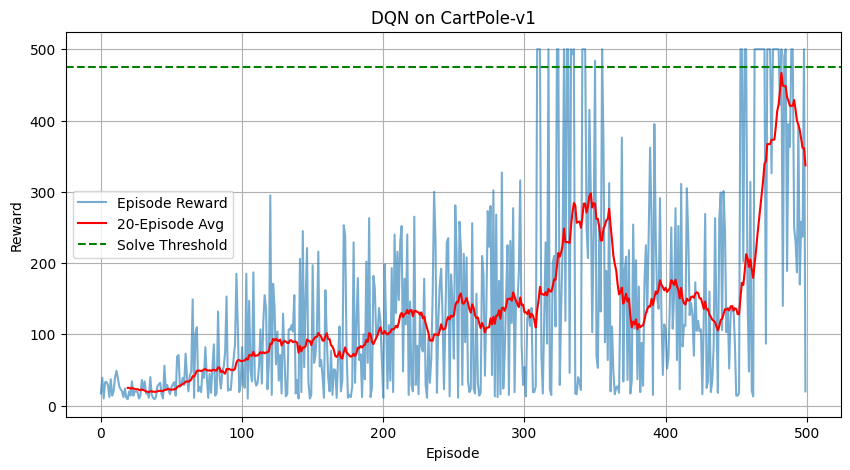

In [22]:
plt.figure(figsize=(10, 5))
plt.plot(rewards, label='Episode Reward', alpha=0.6)
# Smoothed curve
window = 20
smoothed = np.convolve(rewards, np.ones(window)/window, mode='valid')
plt.plot(range(window-1, len(rewards)), smoothed, label=f'{window}-Episode Avg', color='red')
plt.axhline(475, color='green', linestyle='--', label='Solve Threshold')
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title('DQN on CartPole-v1')
plt.legend()
plt.grid()
plt.show()

 ### **Bonus Improvements**

1. Double DQN: Replace `maxₐ’ Q_target(s’, a’)` with
    `Q_target(s’, argmaxₐ Q_policy(s’, a))` → reduces overestimation bias.
2. Prioritized Experience Replay: Sample important transitions (e.g., high TD-error) more often.
3. Huber Loss (`nn.SmoothL1Loss`) instead of MSE → more robust to outliers.
4. Learning rate scheduling or adaptive ε decay.

In [27]:
class QNetwork(nn.Module):
    """
    Neural network that approximates the Q-function for DQN.
    
    Takes a state as input and outputs Q-values for each possible action.
    """
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        """
        Initialize the Q-Network with fully connected layers.
        
        Args:
            state_dim (int): Dimension of the input state (e.g. 4 for CartPole)
            action_dim (int): Number of possible actions (e.g. 2 for CartPole)
            hidden_dim (int): Number of neurons in each hidden layer (default: 128)
        """
        super(QNetwork, self).__init__()
        # First fully connected layer: state → hidden
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        # Second fully connected layer: hidden → hidden
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        # Output layer: hidden → action values (Q-values)
        self.fc3 = nn.Linear(hidden_dim, action_dim)
    
    def forward(self, x):
        """
        Forward pass through the network.
        
        Args:
            x (torch.Tensor): Input state tensor (batch_size, state_dim)
            
        Returns:
            torch.Tensor: Q-values for each action (batch_size, action_dim)
        """
        # First layer + ReLU activation
        x = torch.relu(self.fc1(x))
        # Second layer + ReLU activation
        x = torch.relu(self.fc2(x))
        # Output layer (no activation - raw Q-values)
        return self.fc3(x)

---
**Note:** This notebook is part of a Deep Learning assignment designed and prepared by [Mahdi Golizadeh](mailto:mahdi.golizadeh@gmail.com).

In [28]:
class ReplayBuffer:
    """
    Experience replay buffer for storing and sampling transitions.
    Uses a deque with fixed maximum size (FIFO - First In, First Out).
    """
    def __init__(self, capacity):
        """
        Initialize the replay buffer.
        
        Args:
            capacity (int): Maximum number of transitions to store
        """
        # Double-ended queue with maximum length
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        """
        Store a transition in the buffer.
        
        Args:
            state: Current state (np.array)
            action: Action taken (int)
            reward: Reward received (float)
            next_state: Next state (np.array)
            done: Whether the episode ended (bool)
        """
        # Store transition as a tuple
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        """
        Randomly sample a batch of transitions from the buffer.
        
        Args:
            batch_size (int): Number of transitions to sample
            
        Returns:
            tuple: (states, actions, rewards, next_states, dones) as numpy arrays
        """
        # Randomly select batch_size transitions
        batch = random.sample(self.buffer, batch_size)
        # Unpack tuples into separate sequences
        states, actions, rewards, next_states, dones = zip(*batch)
        # Convert to numpy arrays with appropriate types
        return (
            np.array(states, dtype=np.float32),      # shape: (batch_size, state_dim)
            np.array(actions, dtype=np.int64),       # shape: (batch_size,)
            np.array(rewards, dtype=np.float32),     # shape: (batch_size,)
            np.array(next_states, dtype=np.float32), # shape: (batch_size, state_dim)
            np.array(dones, dtype=np.bool_)          # shape: (batch_size,)
        )

    def __len__(self):
        """Return the current size of the buffer."""
        return len(self.buffer)

In [29]:
def soft_update(target_net, policy_net, tau=0.005):
    """
    Perform a soft update of the target network parameters.
    θ_target ← τ·θ_policy + (1−τ)·θ_target
    
    Args:
        target_net (nn.Module): Target network to be updated
        policy_net (nn.Module): Policy network (source of weights)
        tau (float): Soft update coefficient (usually small, e.g. 0.005)
    """
    # Iterate over all parameter pairs
    for target_param, policy_param in zip(target_net.parameters(), policy_net.parameters()):
        # Soft update formula
        target_param.data.copy_(tau * policy_param.data + (1 - tau) * target_param.data)

In [30]:
def select_action(state, policy_net, epsilon, action_space, device):
    """
    Select an action using ε-greedy policy.
    
    Args:
        state (np.array): Current state
        policy_net (QNetwork): Policy network for Q-value estimation
        epsilon (float): Probability of random action (exploration)
        action_space (gym.Space): Environment action space
        device (torch.device): Device to run the network on ('cpu' or 'cuda')
        
    Returns:
        int: Selected action
    """
    # Exploration: take random action with probability epsilon
    if random.random() < epsilon:
        return action_space.sample()
    
    # Exploitation: take action with highest Q-value
    with torch.no_grad():
        # Convert state to tensor, add batch dimension, move to device
        state_tensor = torch.from_numpy(state).float().unsqueeze(0).to(device)
        # Get Q-values for all actions
        q_values = policy_net(state_tensor)  # shape: (1, action_dim)
        # Select action with highest Q-value
        return q_values.argmax(dim=1).item()

In [31]:
# -----------------------------
# Hyperparameters
# -----------------------------
BATCH_SIZE = 64           # Number of transitions in each training batch
GAMMA = 0.99              # Discount factor for future rewards
EPS_START = 1.0           # Initial exploration rate
EPS_END = 0.01            # Final (minimum) exploration rate
EPS_DECAY = 0.995         # Epsilon decay rate per episode
LR = 1e-3                 # Learning rate for optimizer
BUFFER_CAPACITY = 10000   # Maximum size of replay buffer
TARGET_UPDATE_FREQ = 10   # Not used in this version (soft update is used instead)
MIN_REPLAY_SIZE = 1000    # Minimum buffer size before training starts
NUM_EPISODES = 500        # Maximum number of training episodes

# Device configuration (GPU if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Environment dimensions (specific to CartPole-v1)
state_dim = 4    # Cart position, cart velocity, pole angle, pole angular velocity
action_dim = 2   # Push left / Push right

In [33]:
# Initialize networks
policy_net = QNetwork(state_dim, action_dim).to(device)  # Network we train
target_net = QNetwork(state_dim, action_dim).to(device)  # Stable target network

In [34]:
# Copy initial weights from policy network to target network
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()  # No gradient updates for target network

QNetwork(
  (fc1): Linear(in_features=4, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=2, bias=True)
)

In [35]:
# Optimizer and loss function
optimizer = optim.Adam(policy_net.parameters(), lr=LR)
loss_fn = nn.SmoothL1Loss()           # Huber loss (more robust than MSE)
replay_buffer = ReplayBuffer(BUFFER_CAPACITY)  # Experience replay storage

In [36]:
def train_dqn():
    """
    Main training loop for Deep Q-Network (DQN) on CartPole-v1.
    
    Returns:
        list: List of total rewards obtained in each episode
    """
    # Create environment
    env = gym.make("CartPole-v1")
    episode_rewards = []     # Store reward of each episode
    epsilon = EPS_START      # Start with full exploration

    # Initial hard copy of weights to target network
    target_net.load_state_dict(policy_net.state_dict())

    for episode in range(NUM_EPISODES):
        # Reset environment at start of each episode
        state, _ = env.reset()
        total_reward = 0

        while True:
            # Choose action using ε-greedy policy
            action = select_action(state, policy_net, epsilon, env.action_space, device)

            # Execute action and get next state, reward, termination info
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            # Store the transition in replay buffer
            replay_buffer.push(state, action, reward, next_state, done)
            total_reward += reward
            state = next_state  # Move to next state

            # Train only when we have enough experience
            if len(replay_buffer) > MIN_REPLAY_SIZE:
                # Sample a random batch of transitions
                states, actions, rewards, next_states, dones = replay_buffer.sample(BATCH_SIZE)

                # Convert numpy arrays to PyTorch tensors and move to device
                states = torch.tensor(states, dtype=torch.float32, device=device)
                actions = torch.tensor(actions, dtype=torch.long, device=device)
                rewards = torch.tensor(rewards, dtype=torch.float32, device=device)
                next_states = torch.tensor(next_states, dtype=torch.float32, device=device)
                dones = torch.tensor(dones, dtype=torch.bool, device=device)

                # Get current Q-values for the actions we actually took
                current_q_values = policy_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)

                with torch.no_grad():
                    # Double DQN: select action using policy network, evaluate using target
                    next_actions = policy_net(next_states).argmax(dim=1).unsqueeze(1)
                    next_q_values = target_net(next_states).gather(1, next_actions).squeeze(1)
                    # Target Q-value: reward + discounted future value (if not done)
                    target_q_values = rewards + (GAMMA * next_q_values * (~dones).float())

                # Compute loss (difference between current and target Q-values)
                loss = loss_fn(current_q_values, target_q_values)

                # Backpropagation and optimization step
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                # Soft update target network
                soft_update(target_net, policy_net, tau=0.005)

            # End episode if done
            if done:
                break

        # Decay exploration rate (epsilon) after each episode
        epsilon = max(EPS_END, epsilon * EPS_DECAY)
        episode_rewards.append(total_reward)

        # Print progress every 20 episodes
        if episode % 20 == 0:
            avg_reward = np.mean(episode_rewards[-20:])
            print(f"Episode {episode}, Avg Reward (last 20): {avg_reward:.2f}, ε: {epsilon:.3f}")

        # Early stopping if solved (standard CartPole-v1 criterion)
        if len(episode_rewards) >= 100 and np.mean(episode_rewards[-100:]) >= 475:
            print(f" Solved in {episode} episodes!")
            break

    env.close()
    return episode_rewards

In [37]:
# Run training
rewards = train_dqn()

Episode 0, Avg Reward (last 20): 18.00, ε: 0.995
Episode 20, Avg Reward (last 20): 19.55, ε: 0.900
Episode 40, Avg Reward (last 20): 29.65, ε: 0.814
Episode 60, Avg Reward (last 20): 21.55, ε: 0.737
Episode 80, Avg Reward (last 20): 28.10, ε: 0.666
Episode 100, Avg Reward (last 20): 45.20, ε: 0.603
Episode 120, Avg Reward (last 20): 49.30, ε: 0.545
Episode 140, Avg Reward (last 20): 35.85, ε: 0.493
Episode 160, Avg Reward (last 20): 34.30, ε: 0.446
Episode 180, Avg Reward (last 20): 50.20, ε: 0.404
Episode 200, Avg Reward (last 20): 35.50, ε: 0.365
Episode 220, Avg Reward (last 20): 34.05, ε: 0.330
Episode 240, Avg Reward (last 20): 29.15, ε: 0.299
Episode 260, Avg Reward (last 20): 28.65, ε: 0.270
Episode 280, Avg Reward (last 20): 29.30, ε: 0.245
Episode 300, Avg Reward (last 20): 52.55, ε: 0.221
Episode 320, Avg Reward (last 20): 61.85, ε: 0.200
Episode 340, Avg Reward (last 20): 58.05, ε: 0.181
Episode 360, Avg Reward (last 20): 60.60, ε: 0.164
Episode 380, Avg Reward (last 20): 56

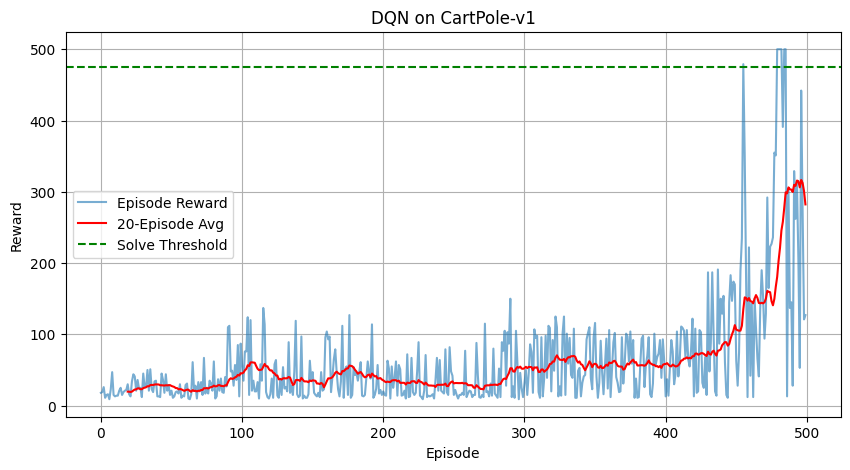

In [38]:
    plt.figure(figsize=(10, 5))
    plt.plot(rewards, label='Episode Reward', alpha=0.6)
    # Smoothed curve
    window = 20
    smoothed = np.convolve(rewards, np.ones(window)/window, mode='valid')
    plt.plot(range(window-1, len(rewards)), smoothed, label=f'{window}-Episode Avg', color='red')
    plt.axhline(475, color='green', linestyle='--', label='Solve Threshold')
    plt.xlabel('Episode')
    plt.ylabel('Reward')
    plt.title('DQN on CartPole-v1')
    plt.legend()
    plt.grid()
    plt.show()

---
**Note:** This notebook is part of a Deep Learning assignment designed and prepared by [Mahdi Golizadeh](mailto:mahdi.golizadeh@gmail.com).